<a href="https://colab.research.google.com/github/IrumShehryar/ML-NLP-Coursework/blob/main/nlp/06-fine-tuning-transformer/Project_03_Fine_Tuning_CustomDataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip uninstall -y transformers
!pip install transformers
!pip install accelerate -U
!pip install transformers datasets

Found existing installation: transformers 5.13.1
Uninstalling transformers-5.13.1:
  Successfully uninstalled transformers-5.13.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 68.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
style.use('dark_background')
import torch
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

# Read the dataset by mounting drive and settimg the *path*

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%cd /content/drive/MyDrive/NLP-course/Course Material/Fine Tuning Transformer

/content/drive/MyDrive/NLP-course/Course Material/Fine Tuning Transformer


In [5]:
df = pd.read_csv('Tweets.csv')

In [6]:
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


# Extract the relevant columns

In [7]:
df = df[['airline_sentiment', 'text']].copy()

In [8]:
df.head()

,airline_sentiment,text
0,neutral,@VirginAmerica What @dhepburn said.
1,positive,@VirginAmerica plus you've added commercials t...
2,neutral,@VirginAmerica I didn't today... Must mean I n...
3,negative,@VirginAmerica it's really aggressive to blast...
4,negative,@VirginAmerica and it's a really big bad thing...


# Check if the data is balanced

<Axes: >

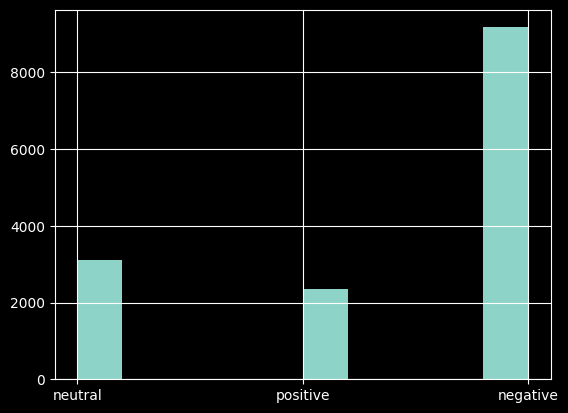

In [9]:
df['airline_sentiment'].hist()

# Map the labels to integers

In [10]:
label_map = {'positive' : 1, 'negative' : 0, 'neutral' : 2}  # map the labels to integers which is required for neural networks.
df['labels'] = df['airline_sentiment'].map(label_map)

In [11]:
df2 = df[['text','labels']]

In [12]:
df2.head()

,text,labels
0,@VirginAmerica What @dhepburn said.,2
1,@VirginAmerica plus you've added commercials t...,1
2,@VirginAmerica I didn't today... Must mean I n...,2
3,@VirginAmerica it's really aggressive to blast...,0
4,@VirginAmerica and it's a really big bad thing...,0


# Fullfilling the requirements of Hugging face dataset

In [13]:
df2.columns =['sentence', 'label'] # saving new csv file with new column names specially important is to change target as label
df2.to_csv('data.csv', index = None) # Converting to csv is important for using hugging face dataset

In [14]:
!head data.csv # two columns in new csv with head in the first column and label in the second column

sentence,label
@VirginAmerica What @dhepburn said.,2
@VirginAmerica plus you've added commercials to the experience... tacky.,1
@VirginAmerica I didn't today... Must mean I need to take another trip!,2
"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have little recourse",0
@VirginAmerica and it's a really big bad thing about it,0
"@VirginAmerica seriously would pay $30 a flight for seats that didn't have this playing.
it's really the only bad thing about flying VA",0
"@VirginAmerica yes, nearly every time I fly VX this “ear worm” won’t go away :)",1
"@VirginAmerica Really missed a prime opportunity for Men Without Hats parody, there. https://t.co/mWpG7grEZP",2


# Transforming our dataset to hugging face dataset

In [15]:
from datasets import load_dataset
raw_dataset = load_dataset('csv', data_files = 'data.csv') # import data to our hugging face datasets. First argument is csv and second argument is path to csv data.

Generating train split: 0 examples [00:00, ? examples/s]

In [16]:
raw_dataset

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 14640
    })
})

# Split the data into training and testing

In [17]:
data = raw_dataset['train'].train_test_split(test_size=0.3, seed=42)

In [20]:
data

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 10248
    })
    test: Dataset({
        features: ['sentence', 'label'],
        num_rows: 4392
    })
})

# Import Tokenizer

In [21]:
from transformers import AutoTokenizer

In [22]:
checkpoint ="distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

# Write function to pass an argument that truncation = True

In [23]:
def tokenize_func(batch):
  return tokenizer(batch['sentence'], truncation = True) # Trainer will handle the padding

In [24]:
tokenized_datasets = data.map(tokenize_func, batched = True)

Map:   0%|          | 0/10248 [00:00<?, ? examples/s]

Map:   0%|          | 0/4392 [00:00<?, ? examples/s]

# Import Training Argumets, trainer and Model

In [25]:
from transformers import TrainingArguments, AutoModelForSequenceClassification, Trainer

In [26]:
model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels =3
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# Set the training Arguments

In [28]:
training_args = TrainingArguments(
    output_dir= 'training_dir',
    eval_strategy='epoch',  # means if we want to evaluate model on validation set
    save_strategy='epoch',        # means save model after every epoch which is not a good idea because you will runout of colab space
    num_train_epochs= 3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size= 64
)

In [31]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
trainer = Trainer(
    model,
    training_args,
    train_dataset = tokenized_datasets['train'],
    eval_dataset = tokenized_datasets['test'],
   data_collator = data_collator,
)

# Train the model

In [32]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.531727,0.455171
2,0.328908,0.469075
3,0.230943,0.570331


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1923, training_loss=0.3165975422891427, metrics={'train_runtime': 191.6085, 'train_samples_per_second': 160.452, 'train_steps_per_second': 10.036, 'total_flos': 358192024288848.0, 'train_loss': 0.3165975422891427, 'epoch': 3.0})

In [33]:
!ls training_dir # we can see the three checkpoints because model is trained on three epochs

checkpoint-1282  checkpoint-1923  checkpoint-641


# load the Save model

In [34]:
from transformers import pipeline

In [35]:
savemodel = pipeline('text-classification', model = 'training_dir/checkpoint-1282', device = 0)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

# Get the test data and test the model

In [36]:
data['test'] # access the test set

Dataset({
    features: ['sentence', 'label'],
    num_rows: 4392
})

In [40]:
y_pred = savemodel(list(data['test']['sentence'])) # run the test set on our saved model to get the test predictions

In [41]:
y_pred

[{'label': 'LABEL_1', 'score': 0.9513874650001526},
 {'label': 'LABEL_1', 'score': 0.9275901913642883},
 {'label': 'LABEL_0', 'score': 0.8828203082084656},
 {'label': 'LABEL_2', 'score': 0.44924917817115784},
 {'label': 'LABEL_1', 'score': 0.5954617857933044},
 {'label': 'LABEL_0', 'score': 0.9965369701385498},
 {'label': 'LABEL_2', 'score': 0.9165941476821899},
 {'label': 'LABEL_2', 'score': 0.73368239402771},
 {'label': 'LABEL_2', 'score': 0.6240107417106628},
 {'label': 'LABEL_0', 'score': 0.9972600936889648},
 {'label': 'LABEL_0', 'score': 0.9854394793510437},
 {'label': 'LABEL_0', 'score': 0.9945161938667297},
 {'label': 'LABEL_1', 'score': 0.9590005278587341},
 {'label': 'LABEL_0', 'score': 0.9969634413719177},
 {'label': 'LABEL_2', 'score': 0.9892526268959045},
 {'label': 'LABEL_1', 'score': 0.7163726687431335},
 {'label': 'LABEL_0', 'score': 0.9401933550834656},
 {'label': 'LABEL_0', 'score': 0.9973199963569641},
 {'label': 'LABEL_0', 'score': 0.9076671600341797},
 {'label': 'L

# Transforming Generic Labels to integers

In [42]:
ypred = []
for i in y_pred:
  if i['label'] == 'LABEL_1':
    ypred.append(1)
  elif i['label'] == 'LABEL_2':
    ypred.append(2)
  else:
    ypred.append(0)

In [43]:
ypred

[1,
 1,
 0,
 2,
 1,
 0,
 2,
 2,
 2,
 0,
 0,
 0,
 1,
 0,
 2,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 2,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 2,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 2,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 2,
 0,
 0,
 0,
 2,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 2,
 2,
 2,
 2,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 2,
 0,
 2,
 0,
 0,
 0,
 2,
 2,
 2,
 2,
 2,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 2,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 2,
 2,
 2,
 0,
 0,
 0,
 0,
 2,
 2,
 2,
 1,
 2,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 2,
 2,
 0,
 0,
 0,
 2,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 2,
 1,
 0,
 0,
 0,
 2,
 0,
 2,
 0,
 0,
 1,
 2,
 0,
 0,
 0,
 1,
 2,
 1,
 0,
 0,
 2,
 2,
 0,
 2,
 2,
 0,
 0,
 0,
 2,
 1,
 0,
 2,
 0,
 0,
 2,
 2,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 2,
 1,
 0,
 0,
 0,
 2,
 0,
 2,


# Print Confusion Matrix and calculate accuracy, precision and recall

In [44]:
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, accuracy_score, ConfusionMatrixDisplay

In [45]:
font = {
    'weight' : 'bold',
    'size'   : 15}
plt.rc('font', **font)

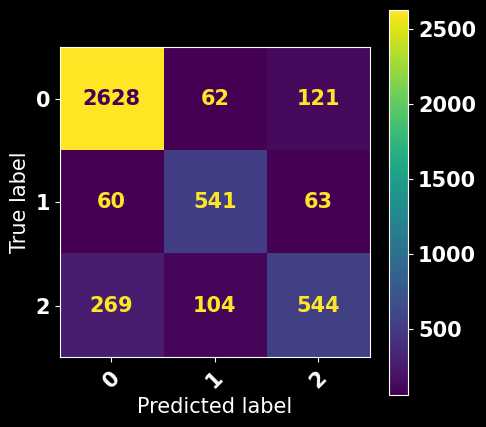

In [46]:
cm = confusion_matrix(data['test']['label'], ypred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels= [0, 1, 2])
disp.plot(xticks_rotation=45)
fig = disp.ax_.get_figure()
fig.set_figwidth(5)
fig.set_figheight(5)
plt.show()

In [48]:
Accuracy = round(accuracy_score(data['test']['label'], ypred, normalize=True), 3)
Precision = round(precision_score(data['test']['label'], ypred, average = 'macro'), 3)   # macro calculate the average value of classes.
Recall = round(recall_score(data['test']['label'], ypred, average = 'macro'), 3)
F1_Score = round(f1_score(data['test']['label'], ypred, average = 'macro'), 3)

print('Accuracy : ', Accuracy)
print(" ")
print('Precision : ', Precision)
print(" ")
print('Recall : ', Recall)
print(" ")
print('F1_Score : ', F1_Score)
print(" ")

Accuracy :  0.845
 
Precision :  0.8
 
Recall :  0.781
 
F1_Score :  0.787
 
